In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

# plt.style.use('default')
sns.set_theme()


In [2]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

You are using a GLFW raw input patch. This is not the official GLFW library.


/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/bin/../lib/libjpeg.9.dylib' (no su

In [3]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [4]:
domain = "cheetah"

In [5]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [6]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [7]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

max_len = 279 # by looking at PPO runs for humanoid

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    train_avg_episode_returns_history = run.scan_history(keys=["train/episode_reward"])
    train_avg_episode_reward = [
        row["train/episode_reward"] for row in train_avg_episode_returns_history
    ]

    update_steps_history = run.scan_history(keys=["train/update_step"])
    update_steps = [row["train/update_step"] for row in update_steps_history]

    steps_history = run.scan_history(keys=["train/step"])
    steps = [row["train/step"] for row in steps_history]

    if run.config["agent_name"] != "ppo":

        eval_avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
        eval_avg_episode_reward = [
            row["eval/episode_reward"] for row in eval_avg_episode_returns_history
        ]


    else:
        eval_avg_episode_reward = train_avg_episode_reward

    eval_update_steps = update_steps

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue



    if run.config["agent_name"] != "ppo":
        max_len = len(update_steps)
    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.

    print("max_len: ", max_len)
    print("len(update_steps): ", len(update_steps[:max_len]))
    print("len(train_avg_episode_reward: ", len(train_avg_episode_reward[:max_len]))
    print("len(eval_avg_episode_reward: ", len(eval_avg_episode_reward[:max_len]))

    temp = dict()
    temp["train/step"] = steps[:max_len]
    temp["train/update_step"] = update_steps[:max_len]
    temp["train/episode_reward"] = train_avg_episode_reward[:max_len]

    temp["eval/episode_reward"] = eval_avg_episode_reward[:max_len]
    temp["eval/update_step"] = update_steps[:max_len]

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 517
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
idx: 50
idx: 60
idx: 70
idx: 80
idx: 90
idx: 100
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
idx: 110
idx: 120
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
ddpg
max_len:  199
len(update_steps):  199
len(train_avg_episode_reward:  199
len(eval_avg_episode_reward:  199
idx: 130
idx: 140
idx: 150
ddpg_beakers_params_continuous
max_len:  199
len(update_steps):  1

In [8]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [9]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [10]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [11]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ppo", agents_new_names["ppo"]
)

In [21]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'TD3 + SC' 'SF + EWC' 'TD3 + EWC'
 'TD3 + Plasticity (last few layers)' 'SF + SC + Attention (Ours)'
 'TD3 + P-last' 'TD3 + CBP' 'SF + SC (Ours)' 'SF' 'PPO']


In [22]:
print(runs_df)

                                              summary  \
0   {'train/step': [10000, 20000, 30000, 40000, 50...   
1   {'train/step': [10000, 20000, 30000, 40000, 50...   
2   {'train/step': [10000, 20000, 30000, 40000, 50...   
3   {'train/step': [10000, 20000, 30000, 40000, 50...   
4   {'train/step': [10000, 20000, 30000, 40000, 50...   
..                                                ...   
71  {'train/step': [10000, 190000, 538333.33333333...   
72  {'train/step': [10000, 190000, 538333.33333333...   
73  {'train/step': [10000, 190000, 538333.33333333...   
74  {'train/step': [10000, 190000, 538333.33333333...   
75  {'train/step': [10000, 190000, 538333.33333333...   

                                               config  \
0   {'mode': 'full_train_run_forward', 'seed': 291...   
1   {'mode': 'full_train_run_forward', 'seed': 582...   
2   {'mode': 'full_train_run_forward', 'seed': 126...   
3   {'mode': 'full_train_run_forward', 'seed': 873...   
4   {'mode': 'full_train_run_f

In [23]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [24]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (76, 5)


In [25]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

   agent_name  agent_seed                                         train/step  \
0         TD3         291  [10000, 20000, 30000, 40000, 50000, 60000, 700...   
1         TD3         582  [10000, 20000, 30000, 40000, 50000, 60000, 700...   
2         TD3        1261  [10000, 20000, 30000, 40000, 50000, 60000, 700...   
3         TD3         873  [10000, 20000, 30000, 40000, 50000, 60000, 700...   
4         TD3        1358  [10000, 20000, 30000, 40000, 50000, 60000, 700...   
..        ...         ...                                                ...   
71        PPO         291  [10000, 190000, 538333.3333333334, 886111.1111...   
72        PPO         388  [10000, 190000, 538333.3333333334, 886111.1111...   
73        PPO         485  [10000, 190000, 538333.3333333334, 886111.1111...   
74        PPO         582  [10000, 190000, 538333.3333333334, 886111.1111...   
75        PPO         679  [10000, 190000, 538333.3333333334, 886111.1111...   

                                    tra

In [26]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [27]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [28]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [29]:
print(runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]]["train/update_step"].max())

990500.7499250075


In [30]:
runs_df[runs_df["agent_name"] == agents_new_names["ppo"]] = runs_df[runs_df["agent_name"] == agents_new_names["ppo"]][runs_df[runs_df["agent_name"] == agents_new_names["ppo"]]["train/update_step"] <= 990500]

In [31]:
from scipy.integrate import trapezoid

def compute_auc(group):
    return trapezoid(group["train/episode_reward"], group["train/update_step"])

In [32]:
runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "train/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "train/update_step"
].values

runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "eval/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "eval/update_step"
].values

In [35]:
print(len(runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "train/update_step"
].values))


print(len(runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "train/update_step"
].values))

1393
1393


In [36]:
print(len(runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]]["train/step"]))

1393


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_64550/2994189414.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_64550/2994189414.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
/var/f

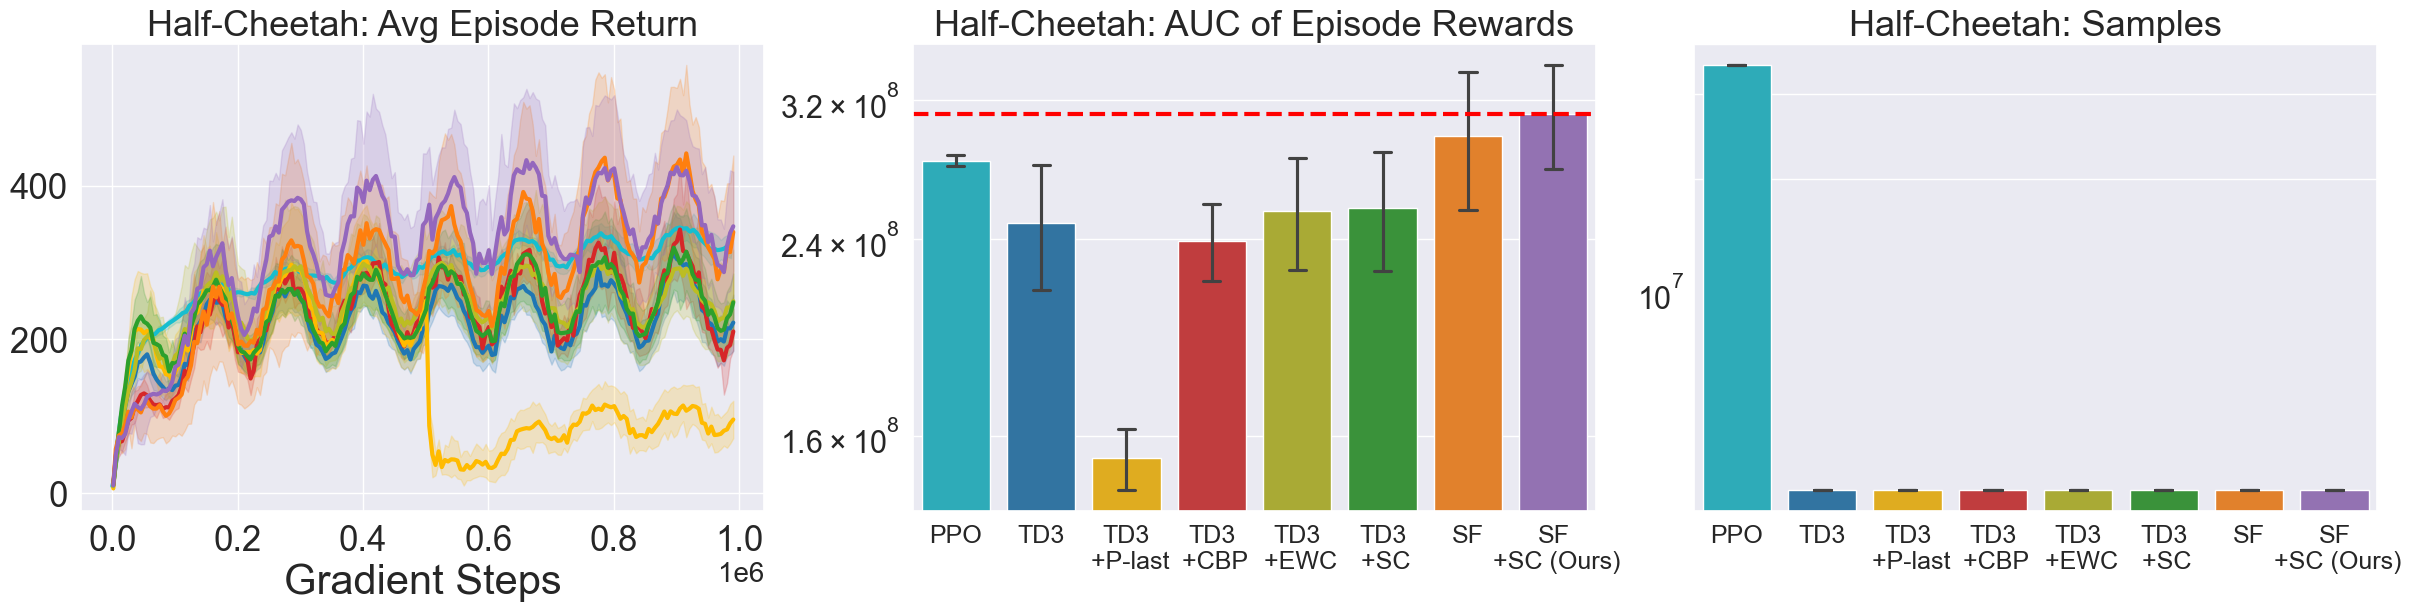

In [41]:
# FOR PPO ANALYSIS ONLY

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
# LEFT
sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ppo"]],
    label=agents_new_names["ppo"],
    color=color_code[agents_new_names["ppo"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

# agents_to_plot = ["PPO", "DDPG", "SF", "DDPG + SC", "SF + SC (Ours)",]
agents_to_plot = ["PPO", "TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)

# match the order in subset["agent_name_pretty"] with the order in agents_to_plot
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)

eps = 1e-12  # in case any values are 0
subset = subset.copy()
# subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))

# print(subset[subset["agent_name"] == agents_new_names["sf_simple"]]["AUC_log10"])


sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)


subset_last_rows = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
subset_last_rows["agent_name_pretty"] = pd.Categorical(subset_last_rows["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
sns.barplot(data=subset_last_rows, x="agent_name_pretty", y="train/step", palette=color_code, ax=axes[2], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

# for i, bar in enumerate(axes[1].patches):
#     x = bar.get_x()
#     y = bar.get_y()
#     w = bar.get_width()
#     h = bar.get_height()
#     if i % 2 == 0:
#         before = h
#     else:
#         pct_gain = 100 * (h - before) / before
#         if pct_gain > 0:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"+{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#         else:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"-{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#
#     print(i, x, y, w, h)

axes[0].set_title("Half-Cheetah: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Gradient Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Half-Cheetah: AUC of Episode Rewards", fontsize=26)
axes[1].tick_params(axis="x", labelsize=18)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].tick_params(axis='y', which='minor', labelsize=0)

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)


axes[2].set_xlabel("", fontsize=14)
axes[2].set_ylabel("", fontsize=14)
axes[2].set_title("Half-Cheetah: Samples", fontsize=26)
axes[2].tick_params(axis="x", labelsize=18)
axes[2].tick_params(axis="y", labelsize=22)
axes[2].set_yscale("log")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[2].yaxis.get_offset_text().set_fontsize(18)
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10))
axes[2].tick_params(axis='y', which='minor', labelsize=22)

filename = "ppo_comparison_" + domain + "_" + cfg.mode
# fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".pdf")
plt.show()


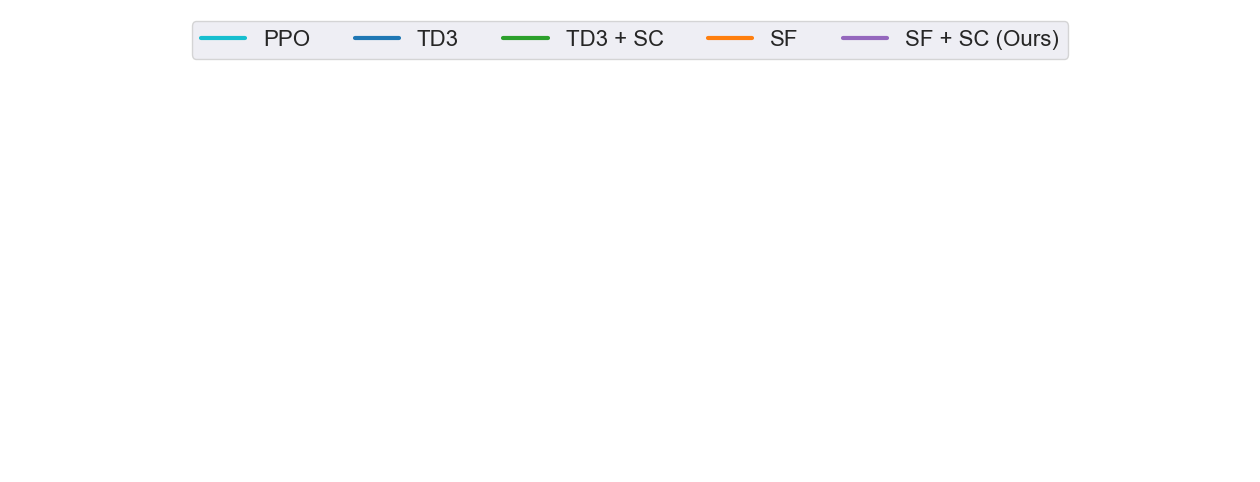

In [37]:
"""
This plot is only used for making legends!!!!
"""

# Plot for Plasticity-Stability Analysis

# from matplotlib.ticker import MaxNLocator, LogLocator
# plt.close()
# fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
#     label=agents_new_names["ddpg_continual_backprop"],
#     color=color_code[agents_new_names["ddpg_continual_backprop"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
#     label=agents_new_names["ddpg_online_ewc"],
#     color=color_code[agents_new_names["ddpg_online_ewc"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
#     label=agents_new_names["ddpg_beakers_params_continuous"],
#     color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
#     label=agents_new_names["sf_simple_beakers_params"],
#     color=color_code[agents_new_names["sf_simple_beakers_params"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# xline = 1e6
# ymin, ymax = ax.get_ylim()
#
# ax.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
# ax.text(
#     xline,                      # x position (same as line)
#     ymin + 0.3* (ymax - ymin),   # 40% above the bottom,
#     "Plasticity Inj.",
#     rotation=90,                # vertical text
#     color="red",
#     ha="right", va="top",       # horizontal/vertical alignment
#     fontsize=18
# )
#
# # plt.title("Half-Cheetah: Avg Episode Return", fontsize=26)
# plt.xlabel("Steps", fontsize=30)
# plt.ylabel("", fontsize=30)
# # plt.legend(loc="upper left", fontsize=16, ncol=2)
# plt.legend(
#     loc="upper center",          # center horizontally
#     bbox_to_anchor=(0.5, 1),  # (x=0.5 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ center, y>1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ move upward)
#     fontsize=16,
#     ncol=2                       # optional: make legend entries spread in columns
# )
# plt.xticks(fontsize=25)
# plt.yticks(fontsize=25)
# ax.xaxis.get_offset_text().set_fontsize(20)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=5))


from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color=color_code[agents_new_names["ppo"]], lw=3, label=agents_new_names["ppo"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg"]], lw=3, label=agents_new_names["ddpg"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_beakers_params_continuous"]], lw=3, label=agents_new_names["ddpg_beakers_params_continuous"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple"]], lw=3, label=agents_new_names["sf_simple"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple_beakers_params"]], lw=3, label=agents_new_names["sf_simple_beakers_params"]),
]

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")               # hide axes
plt.legend(
    handles=custom_lines,
    loc="upper center",          # center horizontally
    bbox_to_anchor=(0.5, 1),  # (x=0.5 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ center, y>1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿ move upward)
    fontsize=16,
    ncol=6                       # optional: make legend entries spread in columns
)

filename = "ppo_comparisons_make_title" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()
